# Top tagging 

This notebook is dedicated to exploring the dataset and visualizing the features to gain insights into the data distribution and relationships between variables. We will use various plotting techniques to understand the characteristics of the dataset and identify any patterns or anomalies that may be present. 

The 3 main datasets wil be:
- **Top tagging**: This dataset contains information about top quark tagging, which is a technique used in particle physics to identify top quarks in high-energy collisions. The features in this dataset may include various kinematic variables and jet substructure observables that are relevant for top quark identification.
- **Quark-gluon jet tagging**: This dataset contains information about quark-gluon jet tagging, which is a technique used to distinguish between jets originating from quarks and gluons. The features in this dataset may include various jet substructure observables and kinematic variables that are relevant for quark-gluon discrimination.
- **Higgs tagging**: This dataset contains information about Higgs boson tagging, which is a technique used to identify Higgs bosons in high-energy collisions. The features in this dataset may include various kinematic variables and jet substructure observables that are relevant for Higgs boson identification.

We can find the dataset in the following path: `../data/raw/top/val.h5`. We use the val test to not load 1 GB from train set. We will load the dataset and perform some exploratory data analysis to understand the distribution of the features and the relationships between them. We will start by loading the dataset and displaying some basic information about it, such as the number of samples, the number of features, and the distribution of the target variable. We will then create various plots to visualize the data, such as histograms, scatter plots, and correlation matrices. This will help us identify any patterns or anomalies in the data that may be relevant for our analysis.

**Description taken from the original source:** [zenodo](https://zenodo.org/records/2603256)

A set of MC simulated training/testing events for the evaluation of top quark tagging architectures.

In total 1.2M training events, 400k validation events and 400k test events. Use “train” for training, “val” for validation during the training and “test” for final testing and reporting results.

Description

- 14 TeV, hadronic tops for signal, qcd diets background, Delphes ATLAS detector card with Pythia8

- No MPI/pile-up included

- Clustering of  particle-flow entries (produced by Delphes E-flow) into anti-kT 0.8 jets in the pT range [550,650] GeV

- All top jets are matched to a parton-level top within ∆R = 0.8, and to all top decay partons within 0.8

- Jets are required to have |$\eta$| < 2

- The leading 200 jet constituent four-momenta are stored, with zero-padding for jets with fewer than 200

- Constituents are sorted by pT, with the highest pT one first

- The truth top four-momentum is stored as truth_px etc.

- A flag (1 for top, 0 for QCD) is kept for each jet. It is called is_signal_new

- The variable "ttv" (= test/train/validation) is kept for each jet. It indicates to which dataset the jet belongs. It is redundant as the different sets are already distributed as different files.

In [2]:
# Cargamos las librerías necesarias
import h5py
import hdf5plugin

In [3]:
try:
    with h5py.File('../data/raw/top/val.h5', 'r') as f:
        print("File keys:", list(f.keys()))
        table = f['table']
        print("Table keys:", list(table.keys()))
        
        print("\n_i_table keys:", list(table['_i_table'].keys())) 
        print("table columns:", list(table['table'].dtype.names))

except Exception as e:
    print(f"Error loading data using hdf5plugin: {e}")

File keys: ['table']
Table keys: ['_i_table', 'table']

_i_table keys: ['index']
table columns: ['index', 'values_block_0', 'values_block_1']


**_i_table key**

In [4]:
try:
    with h5py.File('../data/raw/top/val.h5', 'r') as f:
        table = f['table']['_i_table']['index']
        print("_i_table keys:", list(table.keys()), "\n")
        
        for key in table.keys():
            print(f"{key}: shape {table[key].shape}, dtype {table[key].dtype}")

except Exception as e:
    print(f"Error loading data using hdf5plugin: {e}")

_i_table keys: ['abounds', 'bounds', 'indices', 'indicesLR', 'mbounds', 'mranges', 'ranges', 'sorted', 'sortedLR', 'zbounds'] 

abounds: shape (384,), dtype int64
bounds: shape (3, 127), dtype int64
indices: shape (3, 131072), dtype uint32
indicesLR: shape (131072,), dtype uint32
mbounds: shape (384,), dtype int64
mranges: shape (3,), dtype int64
ranges: shape (3, 2), dtype int64
sorted: shape (3, 131072), dtype int64
sortedLR: shape (131201,), dtype int64
zbounds: shape (384,), dtype int64


This `_i_table` entry is a list of Optimized Index, so we will focus on `table` entry.

**table key**

In [5]:
try:
    with h5py.File('../data/raw/top/val.h5', 'r') as f:   
        table = f['table']['table']
        print("Table keys:", list(table.dtype.names), "\n")
        
        for key in table.dtype.names:
            print(f"{key}: shape {table[key].shape}, dtype {table[key].dtype}")
except Exception as e:
    print(f"Error loading data using hdf5plugin: {e}")

Table keys: ['index', 'values_block_0', 'values_block_1'] 

index: shape (403000,), dtype int64
values_block_0: shape (403000, 804), dtype float32
values_block_1: shape (403000, 2), dtype int64


Let's see what is inside of `values_block_0` and `values_block_1`.

## Data exploration

In [6]:
import polars as pl
#import matplotlib.pyplot as plt
#import seaborn as sns
import numpy as np
#import h5py
#import hdf5plugin

The description mentions store the four-momenta of the leading 200 jet constituyents and the four-momenta of the truth top. In order to know which was stored firts lets see the statistic description of the 0 and 800 file.

In [7]:
# Load the data
try:
    with h5py.File('../data/raw/top/val.h5', 'r') as f:
        table = f['table']['table']
        # We take just 100 000 file to this first part
        x_top_data = table['values_block_0'][:]
        y_top_data = table['values_block_1'][:]

        df_comprobation = pl.DataFrame({
            "px_particle_1": x_top_data[:, 0],
            "px_truth_top": x_top_data[:, 800]
        })
        x_df = pl.DataFrame(x_top_data[:100000, :20])
        print(x_df.describe())
        print(df_comprobation.describe())

except Exception as e:
    print(f"Error: {e}")

shape: (9, 21)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ column_0  ┆ column_1  ┆ column_2  ┆ … ┆ column_16 ┆ column_17 ┆ column_18 ┆ column_1 │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ 9        │
│ str       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 100000.0  ┆ 100000.0  ┆ 100000.0  ┆ … ┆ 100000.0  ┆ 100000.0  ┆ 100000.0  ┆ 100000.0 │
│ null_coun ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ mean      ┆ 232.35685 ┆ 0.420741  ┆ -0.147117 ┆ … ┆ 48.688019 ┆ 0.08361   

We can see zeros in the 800-th column and also bigger energy. This means that the first column is for the first jet constituent, and the 800-th is for the truth top.

Now, let's analice the subparticles.

In [8]:
SEED = 42

## Data visualization

Now let´s see de general distributions of the features.

In [9]:
# import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
# import numpy as np
# import h5py
# import hdf5plugin

In [10]:
# first rows of y_top_data
print("First rows of y_top_data:")
print(y_top_data[:5])

# Statictic description of y_top_data
print("\nStatictic description of y_top_data:")
print(pl.DataFrame(y_top_data).describe())

First rows of y_top_data:
[[2 0]
 [2 0]
 [2 0]
 [2 0]
 [2 0]]

Statictic description of y_top_data:
shape: (9, 3)
┌────────────┬──────────┬──────────┐
│ statistic  ┆ column_0 ┆ column_1 │
│ ---        ┆ ---      ┆ ---      │
│ str        ┆ f64      ┆ f64      │
╞════════════╪══════════╪══════════╡
│ count      ┆ 403000.0 ┆ 403000.0 │
│ null_count ┆ 0.0      ┆ 0.0      │
│ mean       ┆ 2.0      ┆ 0.499993 │
│ std        ┆ 0.0      ┆ 0.500001 │
│ min        ┆ 2.0      ┆ 0.0      │
│ 25%        ┆ 2.0      ┆ 0.0      │
│ 50%        ┆ 2.0      ┆ 0.0      │
│ 75%        ┆ 2.0      ┆ 1.0      │
│ max        ┆ 2.0      ┆ 1.0      │
└────────────┴──────────┴──────────┘


We can conclude that the first column of `values_block_1` is for the kind of dataset, 1 for train, 2, for val and 3 for test. the second column is the label, 1 for signal (top) and 0 for background (QCD).

We will take only 50 000 samples to not overload the notebook. We will use a log scale for the energy distribution to better visualize the range of values.

In [11]:
x_sample = x_top_data[:200000, :]
y_sample = y_top_data[:200000, 1]

# Central axis momenta
jet_E = np.sum(x_sample[:, 0:800:4], axis=1)
jet_px = np.sum(x_sample[:, 1:800:4], axis=1)
jet_py = np.sum(x_sample[:, 2:800:4], axis=1)
jet_pz = np.sum(x_sample[:, 3:800:4], axis=1)

# invariant mass of the jet
jet_mass = np.sqrt(np.clip(jet_E**2 - (jet_px**2 + jet_py**2 + jet_pz**2), 0.0, None))

# Compute derived quantities
jet_pt = np.sqrt(jet_px**2 + jet_py**2)
jet_theta = np.arctan2(jet_pt, jet_pz)
jet_eta = -np.log(np.tan(jet_theta / 2.0), where=(jet_theta > 0), out=np.zeros_like(jet_theta))
jet_phi = np.arctan2(jet_py, jet_px)

# Extract particle-level features using the first 5 particles of each jet
particles_px = x_sample[:, 0:20:4].flatten()
particles_py = x_sample[:, 1:20:4].flatten()
particles_pz = x_sample[:, 2:20:4].flatten()

jet_eta_rep = np.repeat(jet_eta, 5)
jet_phi_rep = np.repeat(jet_phi, 5)
y_rep = np.repeat(y_sample, 5)

# compute particle angles
p_pt = np.sqrt(particles_px**2 + particles_py**2)
p_theta = np.arctan2(p_pt, particles_pz)
p_eta = -np.log(np.tan(p_theta / 2.0), where=(p_theta > 0), out=np.zeros_like(p_theta))
p_phi = np.arctan2(particles_py, particles_px)
p_energy = x_sample[:, 3:20:4].flatten()


In [12]:
print("Suma de la columna 0:", np.sum(x_sample[:, 0]))
print("Suma de la columna 3:", np.sum(x_sample[:, 3]))
print("Máximo absoluto en las primeras 4 columnas:", [np.max(np.abs(x_sample[:, i])) for i in range(4)])

Suma de la columna 0: 4.6513904e+07
Suma de la columna 3: -68026.39
Máximo absoluto en las primeras 4 columnas: [np.float32(2139.986), np.float32(606.2596), np.float32(623.33417), np.float32(2058.4358)]


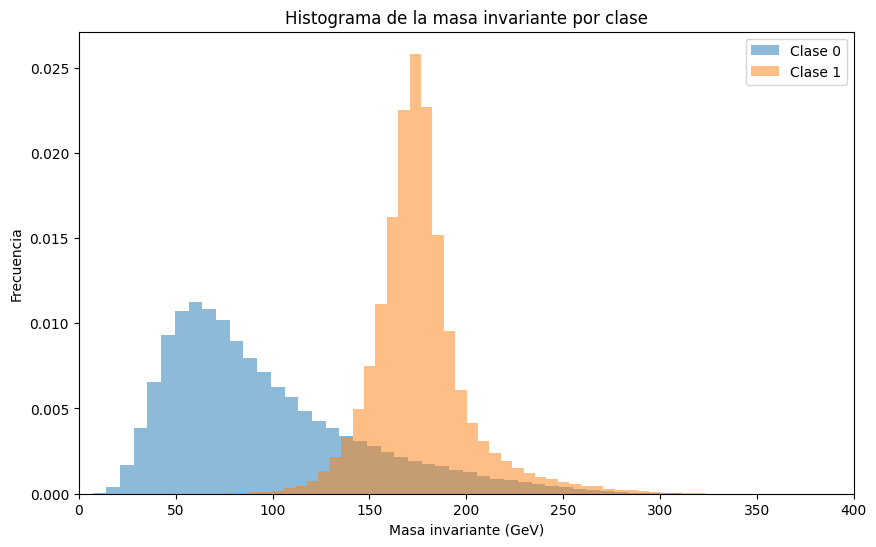

In [13]:
# Histograma normalizado de la masa invariante por clase
plt.figure(figsize=(10, 6))
plt.hist(jet_mass[y_sample == 0], bins= 50, alpha=0.5, label='Clase 0', density=True)
plt.hist(jet_mass[y_sample == 1], bins= 50, alpha=0.5, label='Clase 1', density=True)
plt.xlabel('Masa invariante (GeV)')
plt.ylabel('Frecuencia')
plt.legend()
plt.title('Histograma de la masa invariante por clase')
plt.xlim(-0.04, 400)  # Ajusta los límites del eje x según tus datos
plt.show()

In [14]:
# dataframe
df_real = pl.DataFrame({
    "delta_eta": p_eta - jet_eta_rep,
    "delta_phi": p_phi - jet_phi_rep,
    "energy": p_energy,
    "class": y_rep
}).filter( #((pl.col("delta_eta") != 0) | (pl.col("delta_phi") != 0)) \
(pl.col("energy") > 1e-5))

top_data = df_real.filter(pl.col("class") == 1)
background_data = df_real.filter(pl.col("class") == 0)

In [15]:
# --- Style ---
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "font.family": "serif"
})

# Definition of colors
TOP_COLOR = '#1f77b4'  # Blue for the signal (Hadronic Top)
QCD_COLOR = '#9467bd'  # Purple for the background (QCD Di-jets)

# -------------------------------------------------------------

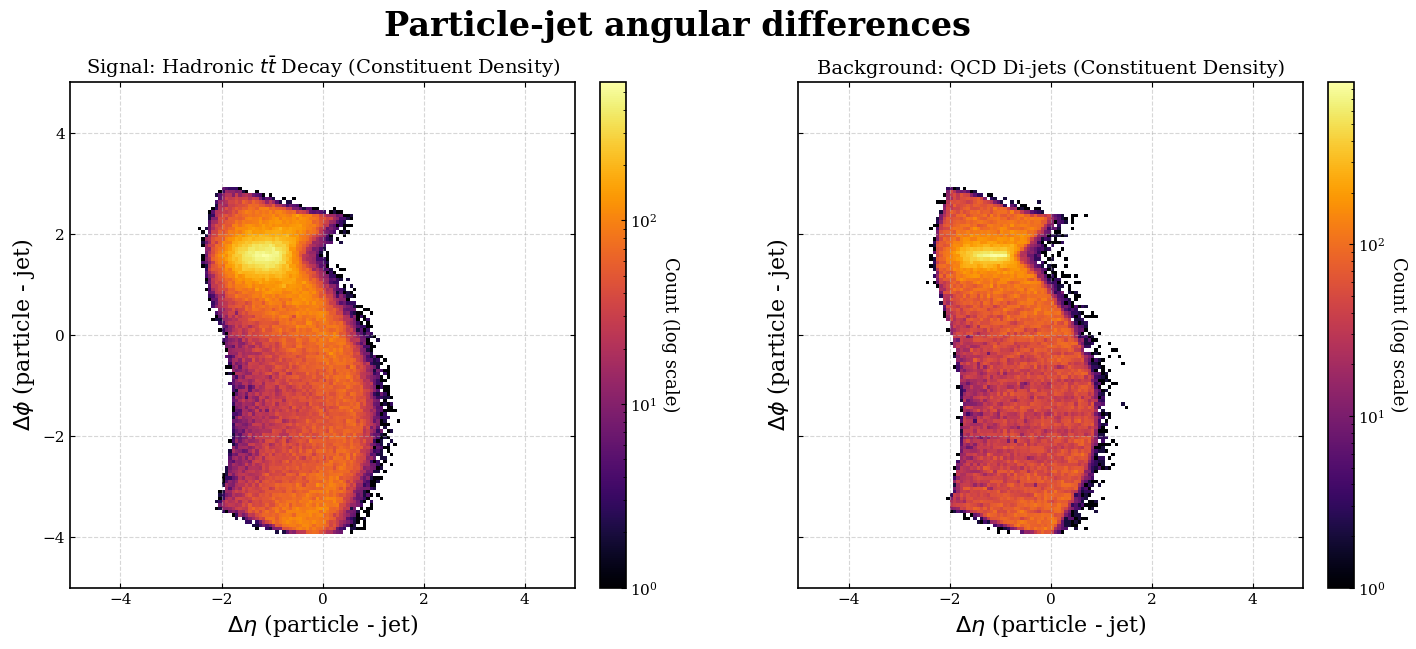

In [16]:
# sig vs bkg
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharex=True, sharey=True)
img_range = [[-5.0, 5.0], [-5.0, 5.0]]
bin_resolution = 150

# Top quark signal
im0 = axes[0].hist2d(top_data["delta_eta"].to_numpy(), 
                    top_data["delta_phi"].to_numpy(), 
                    bins=bin_resolution, 
                    range=img_range,
                    cmap="inferno",
                    norm=LogNorm())
cbar0 = fig.colorbar(im0[3], ax=axes[0], fraction=0.046, pad=0.04)
cbar0.set_label("Count (log scale)", rotation=270, labelpad=15)
axes[0].set_title(r"Signal: Hadronic $t\bar{t}$ Decay (Constituent Density)", fontsize=14)
axes[0].set_xlabel("$\\Delta \\eta$ (particle - jet)", fontsize=16)
axes[0].set_ylabel("$\\Delta \\phi$ (particle - jet)", fontsize=16)

# Background
im1 = axes[1].hist2d(background_data["delta_eta"].to_numpy(), 
                    background_data["delta_phi"].to_numpy(), 
                    bins=bin_resolution, 
                    range=img_range,
                    cmap="inferno",
                    norm=LogNorm())
cbar1 = fig.colorbar(im1[3], ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label("Count (log scale)", rotation=270, labelpad=15)
axes[1].set_title("Background: QCD Di-jets (Constituent Density)", fontsize=14)
axes[1].set_xlabel("$\\Delta \\eta$ (particle - jet)", fontsize=16)
axes[1].set_ylabel("$\\Delta \\phi$ (particle - jet)", fontsize=16)

for ax in axes:
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(img_range[0])
    ax.set_ylim(img_range[1])
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Particle-jet angular differences", fontsize=24, fontweight='bold')
plt.tight_layout()#rect=[0, 0, 1, 0.95])
plt.show()

This first plot shows the dispersión of the particles asociated to the jets in the eta-phi space. We can see that the particles are distributed around the jet axis, which is expected since they are constituents of the jet. The color coding indicates the energy of the particles, with higher energy particles being more concentrated around the jet axis. The dispersion of the top is greater than the QCD, which is expected since the top quark decays into three particles, while the QCD jet is a single particle.

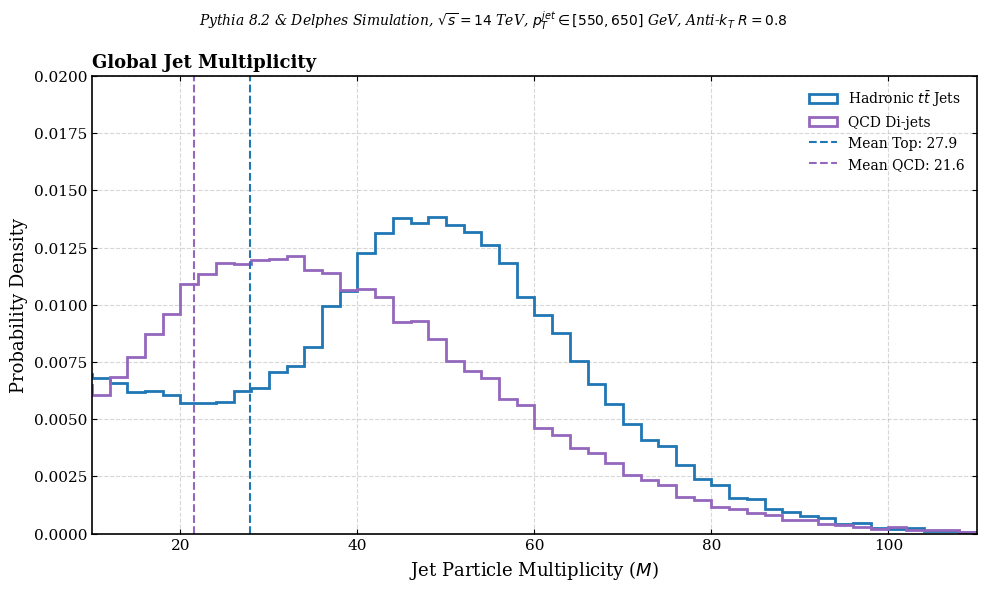

In [17]:
# ==============================================================================
# PANEL 1: GLOBAL EVENT PROPERTIES (2 Subplots)
# ==============================================================================
fig, ax = plt.subplots(1, figsize=(10, 6))

# --- Subplot A: Real Multiplicity Histogram ---
# Count how many constituents with E > 0 each original individual jet has
energy_matrix = x_sample[:, 3::4]
multiplicity_event = np.count_nonzero(energy_matrix > 0, axis=1)

mult_top = multiplicity_event[y_sample == 1]
mult_qcd = multiplicity_event[y_sample == 0]

bins_mult = np.arange(0, 120, 2)
ax.hist(mult_top, bins=bins_mult, histtype="step", lw=2, color=TOP_COLOR, label=r"Hadronic $t\bar{t}$ Jets", density=True)
ax.hist(mult_qcd, bins=bins_mult, histtype="step", lw=2, color=QCD_COLOR, label="QCD Di-jets", density=True)

ax.set_xlabel(r"Jet Particle Multiplicity ($M$)")
ax.set_ylabel("Probability Density")
ax.set_xlim(10, 110)
ax.set_ylim(0, 0.02)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(frameon=False)
ax.set_title("Global Jet Multiplicity", loc="left", fontweight="bold")

# vertical lines with the mean of each distribution
mean_mult_top = np.mean(mult_top)
mean_mult_qcd = np.mean(mult_qcd)
ax.axvline(mean_mult_top, color=TOP_COLOR, linestyle='--', label=f"Mean Top: {mean_mult_top:.1f}")
ax.axvline(mean_mult_qcd, color=QCD_COLOR, linestyle='--', label=f"Mean QCD: {mean_mult_qcd:.1f}")
ax.legend(frameon=False)

fig.suptitle(r"Pythia 8.2 & Delphes Simulation, $\sqrt{s} = 14$ TeV, $p_T^{jet} \in [550, 650]$ GeV, Anti-$k_T$ $R=0.8$", fontsize=10, y=0.98, style="italic")
plt.tight_layout()
# fig.savefig("panel1_top_global_properties.pdf", dpi=300)
plt.show()

With this plot we can see the probability density of the jet multiplicity for the top and QCD jets. We can see that the top jets have a higher multiplicity than the QCD jets, which is expected since the top quark decays into three particles, while the QCD jet is a single particle. The distribution for the top jets is also wider than for the QCD jets, which is also expected since the top quark can decay into different particles with different energies.

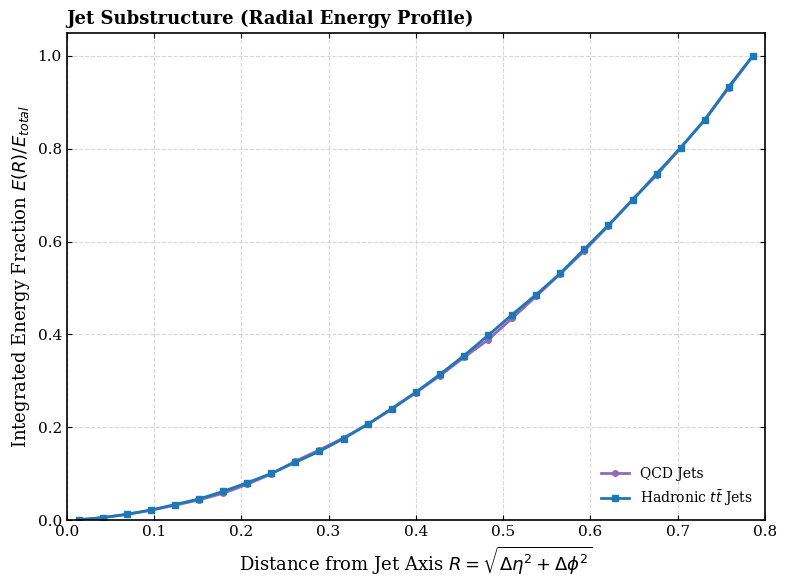

In [18]:
# ==============================================================================
# PANEL 2: INTERNAL GEOMETRY AND ANGULAR DISTRIBUTION (2 Subplots)
# ==============================================================================
fig, ax = plt.subplots(1, figsize=(8, 6))

# --- Subplot A: Radial Energy Profile Limited to R=0.8 ---
df_radial = df_real.with_columns(
    (pl.col("delta_eta")**2 + pl.col("delta_phi")**2).sqrt().alias("r")
)

r_bins = np.linspace(0, 0.8, 30) # Limited to the total cone of the algorithm R=0.8
r_centers = (r_bins[:-1] + r_bins[1:]) / 2
profile_top, profile_qcd = [], []

for i in range(len(r_bins)-1):
    r_min, r_max = r_bins[i], r_bins[i+1]
    pt_sum = (df_radial.filter((pl.col("r") >= r_min) & \
                (pl.col("r") < r_max)).group_by("class").agg(pl.col("energy").sum()).sort("class"))
    
    sum_qcd = pt_sum.filter(pl.col("class") == 0)["energy"].to_numpy()
    sum_top = pt_sum.filter(pl.col("class") == 1)["energy"].to_numpy()
    profile_qcd.append(sum_qcd[0] if len(sum_qcd) > 0 else 0)
    profile_top.append(sum_top[0] if len(sum_top) > 0 else 0)

cum_profile_qcd = np.cumsum(profile_qcd) / np.sum(profile_qcd)
cum_profile_top = np.cumsum(profile_top) / np.sum(profile_top)

ax.plot(r_centers, cum_profile_qcd, marker='o', ls='-', color=QCD_COLOR, label="QCD Jets", lw=2, markersize=4)
ax.plot(r_centers, cum_profile_top, marker='s', ls='-', color=TOP_COLOR, label=r"Hadronic $t\bar{t}$ Jets", lw=2, markersize=4)
ax.set_xlabel(r"Distance from Jet Axis $R = \sqrt{\Delta \eta^2 + \Delta \phi^2}$")
ax.set_ylabel(r"Integrated Energy Fraction $E(R)/E_{total}$")
ax.set_xlim(0, 0.8)
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(frameon=False, loc="lower right")
ax.set_title("Jet Substructure (Radial Energy Profile)", loc="left", fontweight="bold")

plt.tight_layout()
# fig2.savefig("panel2_top_geometry_substructure.pdf", dpi=300)
plt.show()

The radial energy profile shows how the energy of the jet is distributed as a function of the distance from the jet axis. We can see that the top jets have a more dispersed energy distribution around the jet axis, that is way the curve is more gradual, while the QCD jets have a more concentrated energy distribution around the jet axis, that is why the curve is steeper.

ValueError: x and y must have same first dimension, but have shapes (200,) and (201,)

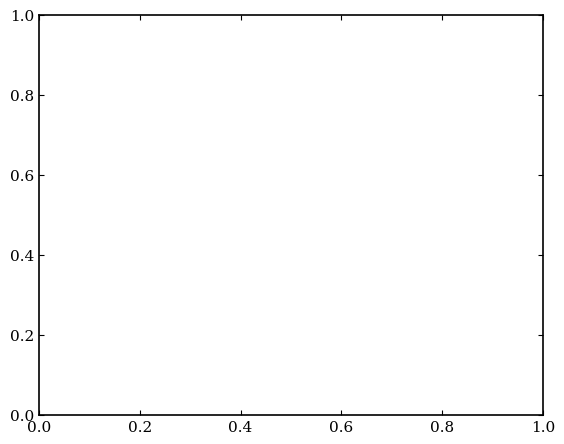

In [19]:
# ==============================================================================
# PARETO KINEMATIC PROCESSING (TOP TAGGING REF. DATASET)
# ==============================================================================
# Isolate the 800 columns of the 200 constituents in Cartesian format (px, py, pz, E)
X_matriz = x_sample
y_target = y_sample    # Target variable (1: Hadronic Top, 0: QCD)

# Extract the transverse components (px, py) by skipping 4 columns at a time
p_x = X_matriz[:, 0::4]
p_y = X_matriz[:, 1::4]

# Calculate the transverse momentum (pt) of each individual particle
pt_matrix = np.sqrt(p_x**2 + p_y**2)

# Perform the cumulative sum along the particle index (column axis)
cumulative_pt = np.cumsum(pt_matrix, axis=1)

# The last cumulative element (column 200) represents the total pt of the complete Jet
total_pt = cumulative_pt[:, -1]
total_pt_safe = np.where(total_pt == 0, 1.0, total_pt) # Safe against empty jets

# Divide each step by the total pt of the jet to obtain the fraction (scale 0 to 1)
pt_fraction_matrix = cumulative_pt / total_pt_safe[:, None]

# Segregate the profile matrices according to the true class of the collider
top_profiles = pt_fraction_matrix[y_target == 1]
qcd_profiles = pt_fraction_matrix[y_target == 0]

# Calculate the mean and standard deviation for each particle index
mean_top = np.mean(top_profiles, axis=0)
std_top = np.std(top_profiles, axis=0)

mean_qcd = np.mean(qcd_profiles, axis=0)
std_qcd = np.std(qcd_profiles, axis=0)

# The X-axis denotes the actual count of integrated particles (1 to 200)
particle_indices = np.arange(1, 201)

# ==============================================================================
# AUTOMATIC TRUNCATION CALCULATION (80% THRESHOLD FOR BOTH)
# ==============================================================================
# Find the first index where BOTH curves exceed 80% (0.8)
both_exceed_80 = (mean_top >= 0.80) & (mean_qcd >= 0.80)
N_cut = int(np.where(both_exceed_80)[0][0] + 1)

# Exact percentage values at that cutoff point
cut_fraction_top = mean_top[N_cut - 1]
cut_fraction_qcd = mean_qcd[N_cut - 1]

# ==============================================================================
# CONSTRUCTION AND RENDERING OF THE DIAGRAM
# ==============================================================================
fig, ax = plt.subplots(figsize=(6.5, 5.2))

# Signal curve (Top Quark) with 1-sigma statistical uncertainty shading
ax.plot(particle_indices, mean_top, color=TOP_COLOR, lw=2.0, label=r"Signal: Hadronic $t\bar{t}$ Jets")
ax.fill_between(particle_indices, mean_top - std_top, mean_top + std_top, 
                color=TOP_COLOR, alpha=0.15, step="mid")

# Background curve (QCD) with 1-sigma statistical uncertainty shading
ax.plot(particle_indices, mean_qcd, color=QCD_COLOR, lw=2.0, label="Background: QCD Di-jets", linestyle="--")
ax.fill_between(particle_indices, mean_qcd - std_qcd, mean_qcd + std_qcd, 
                color=QCD_COLOR, alpha=0.12, step="mid")

# --- CRITICAL INDICATORS OF THE TRUNCATION THRESHOLD ---
# Guide lines for each actual intersection
ax.axhline(y=cut_fraction_top, color=TOP_COLOR, linestyle=':', lw=1.0, alpha=0.7)
ax.axhline(y=cut_fraction_qcd, color=QCD_COLOR, linestyle=':', lw=1.0, alpha=0.7)

# Vertical line in N_cut calculated automatically
ax.axvline(x=N_cut, color='red', linestyle='-.', lw=1.2, 
           label=f"Auto Truncation Target ($N={N_cut}$)")

# Visual collision nodes at the cutoff
ax.plot(N_cut, cut_fraction_top, marker='o', color=TOP_COLOR, markersize=6)
ax.plot(N_cut, cut_fraction_qcd, marker='o', color=QCD_COLOR, markersize=6)

# Explanatory text box with the exact percentage of physics preserved
physics_text = f"Physics Preserved:\nTop Jet: {cut_fraction_top*100:.1f}%\nQCD Jet: {cut_fraction_qcd*100:.1f}%"
ax.text(N_cut + 1.5, 0.50, physics_text, 
        fontsize=9.5, bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray', boxstyle='round,pad=0.5'))

# --- AXIS FORMATTING STYLE ---
ax.set_xlabel("Sorted Constituent Index ($i$)")
ax.set_ylabel(r"Cumulative $p_T$ Fraction $\sum p_{T,i} / p_{T}^{\mathrm{jet}}$")

# Dynamic adjustment of the X-axis zoom to always appreciate the cutoff
ax.set_xlim(1, max(40, N_cut + 10))
ax.set_ylim(0.0, 1.05)

# Subplot title and detector metadata in the upper area
ax.set_title("Constituent Energy Scaling & Pareto Frontier", loc="left", fontweight="bold")
fig.suptitle(r"TopTagging Ref. Dataset, $\sqrt{s} = 14$ TeV, Anti-$k_T$ $R=0.8$, $p_T^{\mathrm{jet}} \in [550, 650]$ GeV", 
             fontsize=9.5, y=0.98, style="italic")

ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

## Feature engeneering

Now is time to establish how we will process the data for traning. The focus is
1) Use global and local features
2) Truncate the jets to a fixed number of constituents, N_cut, that preserves most of the physics. We will use the cumulative pT distribution to determine the optimal N_cut.
3) Normalize the features to ensure that they are on a similar scale, which can help with the training of the model. 

The global features are those that describe the overall properties of the jet, such as its total energy, mass, and transverse momentum. The local features are those that describe the properties of the individual constituents of the jet, such as their energy, momentum, and position. By using both global and local features, we can capture both the overall characteristics of the jet and the detailed information about its constituents, which can help improve the performance of our model.
For the model we select 
- Jets mass $$m_{jet} = \sqrt{E^2 - p_x^2 - p_y^2 - p_z^2}$$
- Multiplicity of the jet, that is the number of constituents with non-zero energy. We calculate this by counting the number of constituents with energy greater than zero.

For the local features, we wil use the spatial coordinates and the relative transverse momentum of the constituents. We will calculate the relative transverse momentum as the ratio of the constituent's transverse momentum to the jet's total transverse momentum from the N_cut leading constituents. This will help us capture the distribution of energy within the jet and how it relates to the overall properties of the jet.
- $\Delta R = \sqrt{(\eta_{i} - \eta_{jet})^2 + (\phi_{i} - \phi_{jet})^2}$
- $p_{T,rel} = \frac{p_{T,i}}{p_{T,\sum N_{cut}}}$

The cumulative pT distribution is a plot that shows the cumulative sum of the transverse momentum (pT) of the jet constituents as a function of the number of constituents. This plot can help us determine the optimal N_cut by showing us how much of the total pT is preserved as we include more constituents. The first try will be the number of particles where the cumulative pT fraction is greater than 80% for both top and QCD jets. This means that we will keep the leading N_cut constituents that preserve at least 80% of the total pT of the jet. Based on the previous plot 

\begin{equation}
    N_{cut} = 15
\end{equation}

With this in mind, all the local features will be in $(0,1)$, we need to normalize the global features. The main diferences between the distributions are in the extreme values, so we will use a log transformation to better visualize the distribution and also to reduce the impact of outliers. We will apply the log transformation to the jet mass, and also we keep the outliers to not lose information about the tails of the distribution, which can be important for the classification task because in the center the distributions are very similar.

After the log transformation, we will use a tanh normalization to scale the features to the range (-1, 1). This will help to ensure that all features are on a similar scale, which can improve the training of the model. Also this avoids the problem of compressing the values in the middle of the distributions.

At this point the code is saved into `src/process/processor_top.py` and the processed data is saved in `data/tt_processed_inputs.npy` and the scaler for the jet mass is saved in `data/scaler_top.pkl`. The processed data contains the following features:
- `m_scaled`: The log-transformed and tanh-normalized jet mass.
- `M_scaled`: The tanh-normalized jet multiplicity.
- `d_R`: The distance of each constituent from the jet axis in the eta-phi space.
- `z_effective`: The relative transverse momentum of each constituent with respect to the first 15 constituents' total transverse momentum.